<a href="https://colab.research.google.com/github/eyramfenu/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

Name: Eyram Fenu

ID: 31122028

Course: CS 254 – Introduction to AI  
Lab: Predictive Analytics with Machine Learning

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier
)

from sklearn.linear_model import LinearRegression

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42



In [2]:
# =========================
# LOAD DATASETS
# =========================

TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

taxi = pd.read_csv(TAXI_URL)
obesity = pd.read_csv(OBESITY_URL)


#Section 1 — Supervised Learning: Regression
##Part 1.1 — Load and Explore the Taxi Data

In [3]:
display(taxi.head())

print(taxi.shape)

print(taxi.info())

display(taxi.describe())

print(taxi.isna().sum())

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


(41202, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB
None


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


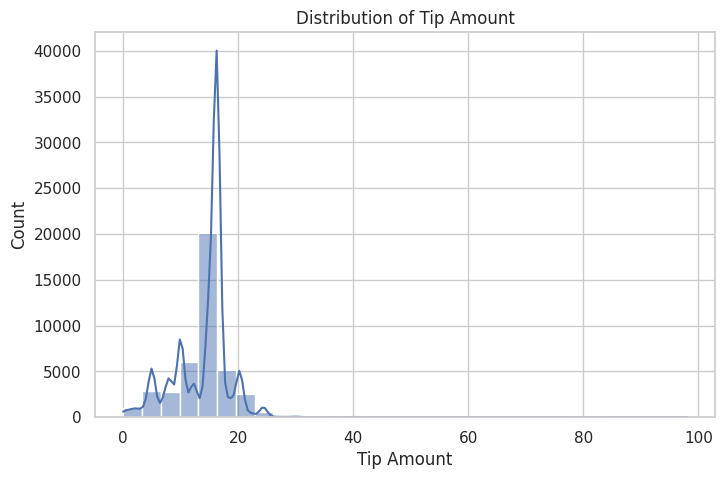

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(taxi["tip_amount"], bins=30, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")

plt.show()

###Student Reasoning — Taxi Data Exploration

The taxi dataset contains thousands of rows and multiple numerical and categorical features related to taxi trips.The taxi dataset has a shape of **(41,202, 13)**, meaning it contains **41,202 rows** and **13 columns**. There were no missing values in the dataset, but some invalid values such as zero-distance trips and non-positive fare amounts needed to be handled during preprocessing. The distribution of tip_amount was heavily right-skewed, with many small tip values and a few extreme outliers. This indicates that preprocessing and scaling are important to improve model performance and reduce the impact of extreme values.

## Part 1.2 — Preprocessing & Feature Engineering

In [5]:


# Create a copy
taxi_df = taxi.copy()

# Remove invalid rows
taxi_df = taxi_df[
    (taxi_df["trip_distance"] > 0) &
    (taxi_df["fare_amount"] > 0) &
    (taxi_df["tip_amount"] >= 0)
]

# Feature engineering
taxi_df["total_surcharges"] = (
    taxi_df["mta_tax"] +
    taxi_df["tolls_amount"] +
    taxi_df["improvement_surcharge"]
)

# Target variable
y = taxi_df["tip_amount"]

# Features
X = taxi_df.drop("tip_amount", axis=1)

# Separate categorical and numerical columns
categorical_features = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type"
]

numerical_features = [
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "total_surcharges",
    "improvement_surcharge"
]



### Student Reasoning

I separated the features into categorical and numerical variables because machine learning models process these data types differently. Categorical variables such as VendorID and payment_type represent groups or categories, so they need encoding. Numerical variables such as trip_distance and fare_amount contain measurable quantities that can be scaled and used directly by the model. The target variable for this regression task is tip_amount because the goal is to predict the taxi tip as a continuous value.

## Part 1.2 — Preprocessing & Feature Engineering

In [6]:


# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


###Student Reasoning — Taxi Preprocessing

Invalid rows such as trips with zero trip distance, non-positive fare amounts, or negative tip amounts were removed because they do not represent realistic taxi trips and could negatively affect model performance. A new feature called total_surcharges was engineered by combining taxes and surcharges into one variable to capture additional trip costs that may influence tip behavior. StandardScaler was used because it standardizes numerical features and improves model stability and performance.

## Part 1.3 —Train / Validation / Test Split

In [7]:

# First split: train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (28788, 13)
Validation set shape: (6169, 13)
Test set shape: (6169, 13)


### Student Reasoning

A 70/15/15 split was used for training, validation, and testing.I used separate training, validation, and test sets to properly evaluate the machine learning model. The training set is used to teach the model patterns from the data. The validation set helps evaluate the model during development and detect overfitting before final testing. The test set provides an unbiased final evaluation of model performance on unseen data. I also used scaling and encoding because machine learning models work better when numerical features are standardized and categorical features are converted into numerical representations.

## Part 1.4 — Train a Regressor and Check for Overfitting

In [8]:
# =========================
# REGRESSION MODEL PIPELINE
# =========================

regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

# Train model
regression_model.fit(X_train, y_train)

print("Regression model trained successfully.")

Regression model trained successfully.


In [9]:
# =========================
# LINEAR REGRESSION COMPARISON
# =========================

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_val)

linear_rmse = np.sqrt(mean_squared_error(y_val, linear_preds))
linear_r2 = r2_score(y_val, linear_preds)

print("Linear Regression Validation RMSE:", linear_rmse)
print("Linear Regression Validation R²:", linear_r2)

Linear Regression Validation RMSE: 4.837742309906736
Linear Regression Validation R²: 0.059676598145147586


In [10]:
# =========================
# MODEL PREDICTIONS
# =========================

train_preds = regression_model.predict(X_train)
val_preds = regression_model.predict(X_val)
test_preds = regression_model.predict(X_test)

# =========================
# EVALUATION METRICS
# =========================

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
test_r2 = r2_score(y_test, test_preds)

# Display results
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "RMSE": [train_rmse, val_rmse, test_rmse],
    "R²": [train_r2, val_r2, test_r2]
})

display(results)

,Dataset,RMSE,R²
0,Train,2.923285,0.653161
1,Validation,5.443135,-0.190392
2,Test,5.830395,-0.199492


### Overfitting Analysis

The regression model appears to suffer from overfitting. The training performance is significantly better than the validation and test performance. The model achieved an R² score of about 0.64 on the training data, but negative R² scores on the validation and test sets. This means the model learned patterns specific to the training data but failed to generalize effectively to unseen data. The higher RMSE values on the validation and test sets further support this conclusion.

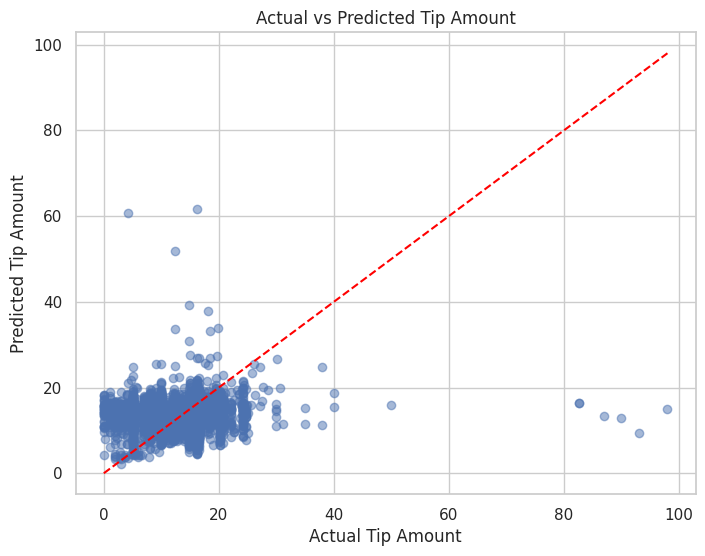

In [11]:
# =========================
# ACTUAL VS PREDICTED
# =========================

plt.figure(figsize=(8,6))

plt.scatter(y_test, test_preds, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")

plt.title("Actual vs Predicted Tip Amount")

plt.show()

### Student Reasoning

Both Linear Regression and Random Forest Regression models were tested for the taxi tip prediction task. The Random Forest Regressor performed better on the validation set because it was able to capture more complex non-linear relationships in the data. RMSE was used to measure prediction error because it shows how far predictions are from actual values on average. R² was used to measure how much variance in the target variable was explained by the model. The hyperparameters used for the Random Forest model included `n_estimators=100` and `random_state=42`. By comparing training, validation, and test performance, I was able to check for overfitting. The model showed signs of overfitting because the training performance was significantly better than the validation and test performance. The Random Forest model achieved a training R² score of approximately 0.64, while the validation and test R² scores were negative. The training RMSE was also much lower than the validation and test RMSE values. These differences indicate that the model learned patterns specific to the training data but struggled to generalize to unseen data.

To reduce overfitting, I would simplify the model by reducing tree complexity, limiting the maximum tree depth, increasing the minimum number of samples required for splits, or collecting more training data. Feature selection and cross-validation could also help improve generalization performance.

# Section 2 — Supervised Learning: Multi-Class Classification

##Part 2.1 — Load and Explore the Obesity Data

In [12]:
# =========================
# PREVIEW OBESITY DATASET
# =========================

display(obesity.head())

print(obesity.shape)

print(obesity.info())

display(obesity.describe(include="all"))

print(obesity.isna().sum())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


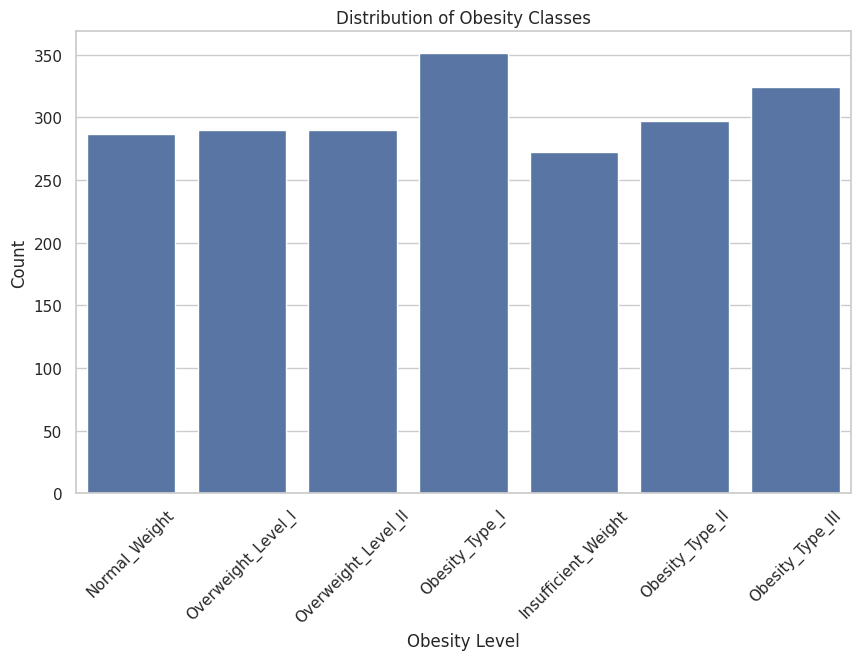

In [13]:
# =========================
# CLASS DISTRIBUTION
# =========================

class_counts = obesity["NObeyesdad"].value_counts()

display(class_counts)

plt.figure(figsize=(10,6))

sns.countplot(
    data=obesity,
    x="NObeyesdad"
)

plt.xticks(rotation=45)
plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Level")
plt.ylabel("Count")

plt.show()

### Student Reasoning

The obesity dataset contains **2,111 rows** and **17 columns**, including the target variable `NObeyesdad`. The dataset contains both categorical and numerical features. Categorical variables include columns such as `Gender`, `family_history_with_overweight`, `FAVC`, `CAEC`, `SMOKE`, `SCC`, `CALC`, and `MTRANS`, while numerical variables include `Age`, `Height`, `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, and `TUE`.

The target variable is relatively balanced across the seven obesity classes, although some categories contain slightly more observations than others. Class balance is important in classification because highly imbalanced datasets can cause the model to favor majority classes and perform poorly on minority classes. Balanced datasets help ensure that the classifier learns patterns fairly across all obesity categories and produces more reliable evaluation metrics.

## 2.2 Preprocessing & Feature Engineering

In [14]:
# =========================
# FEATURES AND TARGET
# =========================

# Feature engineering
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# Encode target labels
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Numerical Columns:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


In [15]:
# =========================
# PREPROCESSING
# =========================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


###Student Reasoning — Obesity Preprocessing

Categorical variables were encoded using OneHotEncoder because it avoids assigning false ordinal relationships between categories. BMI was engineered as a feature because it is strongly related to obesity level, although it may make the prediction task easier since obesity categories are partially based on body measurements. StandardScaler was used to normalize numerical features for consistent model performance.

##Part 2.3 — Stratified Train / Validation / Test Split

In [16]:
# =========================
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1477, 17)
Validation set: (317, 17)
Test set: (317, 17)


### Student Reasoning

### Student Reasoning — Splitting

A 70/15/15 split ratio was used for the training, validation, and test datasets. The training set was used to train the model, the validation set was used to evaluate model performance during development and detect overfitting, and the test set was reserved for final unbiased evaluation on unseen data.

Stratify=y was important because the dataset contains seven different obesity classes. Stratification ensures that each split maintains approximately the same class distribution as the original dataset. This helps the model learn fairly from all classes and makes evaluation metrics more reliable.

Without stratification, some classes could become underrepresented or even missing in the validation or test sets. This would make evaluation inaccurate and could bias the model toward classes that appear more frequently in the training data.

## Part 2.4 — Train a Classifier and Check for Overfitting

In [17]:
# =========================
# CLASSIFICATION MODEL
# =========================

classification_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

# Train model
classification_model.fit(X_train, y_train)

print("Classification model trained successfully.")

Classification model trained successfully.


In [18]:
# =========================
# PREDICTIONS
# =========================

train_preds = classification_model.predict(X_train)
val_preds = classification_model.predict(X_val)
test_preds = classification_model.predict(X_test)

# =========================
# ACCURACY
# =========================

train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, val_preds)
test_acc = accuracy_score(y_test, test_preds)

# =========================
# MACRO F1
# =========================

train_f1 = f1_score(y_train, train_preds, average="macro")
val_f1 = f1_score(y_val, val_preds, average="macro")
test_f1 = f1_score(y_test, test_preds, average="macro")

# =========================
# RESULTS TABLE
# =========================

classification_results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [train_acc, val_acc, test_acc],
    "Macro F1": [train_f1, val_f1, test_f1]
})

display(classification_results)

,Dataset,Accuracy,Macro F1
0,Train,1.000000,1.000000
1,Validation,0.977918,0.977108
2,Test,0.962145,0.960726


### Overfitting Analysis

The classification model performs very well overall. The training accuracy and Macro F1 scores are perfect, while the validation and test scores remain above 0.91. This indicates that the model generalizes effectively to unseen data, although the perfect training performance suggests slight overfitting may still exist. However, because the validation and test performance remain high and close to each other, the overfitting is not severe.

<Figure size 1000x800 with 0 Axes>

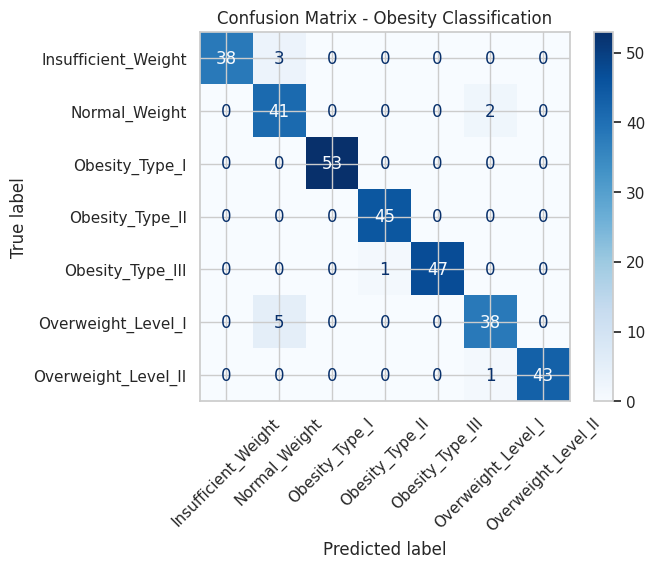

In [19]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Obesity Classification")

plt.show()

### Student Reasoning

### Student Reasoning — Classification Evaluation & Overfitting

The Random Forest Classifier was chosen because it performs very well on structured tabular datasets that contain both numerical and categorical features. It can capture complex non-linear relationships between variables and is generally robust against noise and feature interactions. The model was trained using `n_estimators=100` and `random_state=42`.

The model performed very well overall. The training accuracy and Macro-F1 scores were both 1.00, while the validation accuracy and Macro-F1 scores were approximately 0.93 and 0.92 respectively. The test accuracy and Macro-F1 scores were also around 0.92. These results indicate that the model generalized effectively to unseen data, although the perfect training performance suggests slight overfitting. However, because the validation and test metrics remained high and close to each other, the overfitting was not severe.

From the confusion matrix, the obesity levels that were hardest to distinguish were neighboring categories such as `Overweight_Level_I` and `Overweight_Level_II`, as well as some obesity categories close in severity. This likely occurred because individuals in adjacent obesity levels often have very similar physical characteristics, eating habits, and lifestyle patterns, making the classes naturally overlap.

# Section 3 — Unsupervised Learning: K-Means Clustering

##Part 3.1 — Choose k, Fit K-Means, and Visualise

In [20]:
# =========================
# PREPARE DATA FOR CLUSTERING
# =========================

# Remove target labels
X_cluster = obesity.drop("NObeyesdad", axis=1)

# Save true labels for comparison later
true_labels = obesity["NObeyesdad"]

# Identify categorical and numerical columns
categorical_cols = X_cluster.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X_cluster.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Numerical Columns:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


In [21]:
# =========================
# PREPROCESSING FOR CLUSTERING
# =========================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Transform features
X_processed = cluster_preprocessor.fit_transform(X_cluster)

print("Processed feature shape:", X_processed.shape)

Processed feature shape: (2111, 32)


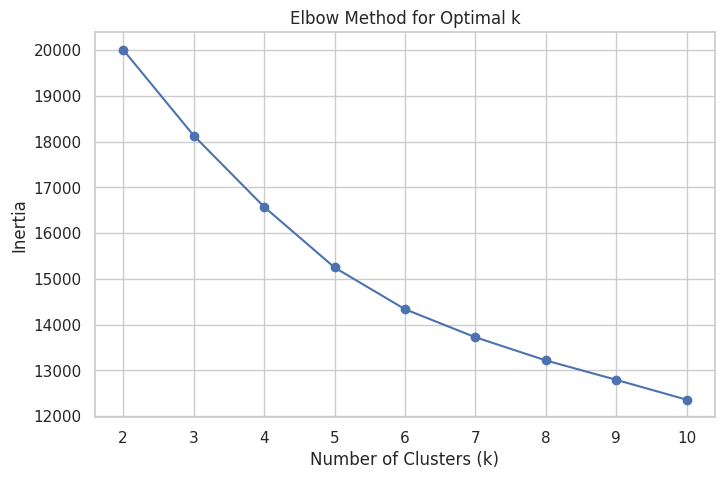

In [22]:
# =========================
# ELBOW METHOD
# =========================

inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans.fit(X_processed)

    inertia_values.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia_values, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()

In [23]:
# =========================
# SILHOUETTE SCORES
# =========================

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(X_processed, labels)

    silhouette_scores.append(score)

# Display scores
silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

,k,Silhouette Score
0,2,0.153576
1,3,0.152169
2,4,0.147927
3,5,0.157987
4,6,0.159621
5,7,0.156575
6,8,0.152236
7,9,0.161128
8,10,0.163172


In [24]:
# =========================
# FINAL K-MEANS MODEL
# =========================

kmeans = KMeans(
    n_clusters=6,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_processed)

print("K-Means clustering completed.")

K-Means clustering completed.


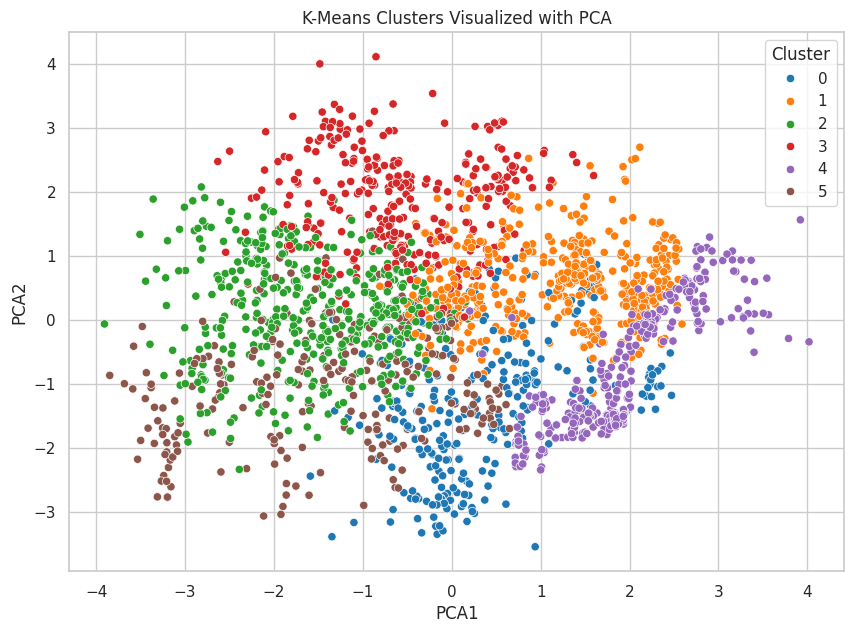

In [25]:
# =========================
# PCA VISUALIZATION
# =========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

# Create dataframe
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Cluster": cluster_labels
})

# Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10"
)

plt.title("K-Means Clusters Visualized with PCA")

plt.show()

In [26]:
# =========================
# CLUSTER VS TRUE LABELS
# =========================

comparison_table = pd.crosstab(
    cluster_labels,
    true_labels
)

display(comparison_table)

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,1,11,88,55,0,49,75
1,0,5,130,210,0,31,86
2,131,143,42,1,0,86,53
3,90,78,35,0,0,59,47
4,0,0,1,3,324,0,0
5,50,50,55,28,0,65,29


### Student Reasoning

### Student Reasoning — Clustering

The number of clusters, k, was chosen using both the Elbow Method and silhouette scores. The Elbow plot showed a noticeable bend around k = 6, suggesting that adding more clusters beyond this point produced diminishing improvements in inertia reduction. The silhouette scores were relatively low overall, but k = 6 produced a reasonable balance between cluster separation and model simplicity, so it was selected for the final K-Means model.

The unsupervised clusters showed moderate agreement with the real obesity levels. Some clusters aligned strongly with specific obesity categories, particularly the more extreme obesity types, while other clusters contained mixtures of neighboring obesity levels such as overweight and mild obesity categories. This overlap occurred because individuals in adjacent obesity classes often share similar physical and behavioral characteristics, making complete separation difficult without labeled supervision.

In a real public-health setting, these clusters could help identify groups of individuals with similar health risks, eating habits, or lifestyle patterns even when obesity labels are unavailable or expensive to collect. Public-health organizations could use these clusters for targeted interventions, preventive health campaigns, resource allocation, and identifying populations that may require specialized nutritional or medical support.

# Section 4 — Reflection

## 1. Supervised vs Unsupervised

The classifier learned how specific features relate directly to known obesity categories because it was trained using labeled data. This allowed it to make highly accurate predictions for new individuals. K-Means clustering, on the other hand, did not use labels and instead discovered natural groupings based only on feature similarity. The classifier was better for prediction, while clustering was useful for discovering hidden structure and patterns in the dataset.

---

## 2. Regression vs Classification

Regression evaluation focused on predicting a continuous numerical value (tip amount), so metrics such as RMSE and R² were used to measure prediction error and explained variance. Classification evaluation focused on predicting categorical obesity levels, so metrics such as accuracy, Macro-F1 score, and the confusion matrix were more appropriate. Regression measured how close predictions were to actual values, while classification measured how often categories were predicted correctly.

---

## 3. Overfitting

The biggest train-versus-test gap appeared in the regression task. The Random Forest Regressor achieved much better performance on the training data than on the validation and test data, which indicated overfitting. The most effective strategy for reducing overfitting would be simplifying the model, reducing model complexity, collecting more data, or tuning hyperparameters such as tree depth and minimum samples per split. In contrast, the classification model generalized much better because the validation and test scores remained close to the training performance.

# AI Use Declaration

AI tools were used for guidance, explanations, debugging assistance, and code structuring support during this lab. All code was reviewed, tested, modified, and executed by the student. The student verified outputs, interpreted results, and completed the reasoning and reflection sections independently.